In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore') 


In [2]:
hd=pd.read_csv("C:/Users/sweth/Downloads/Heart Disease Dataset .csv")

In [3]:
hd.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Waist_cm,Smoking,Alcohol,PhysicalActivity,...,Oldpeak,STSlope,DailySteps,HRV,WearableECGAlerts,MedicationAdherence,RemoteMonitoringFreq,AQIExposure,AvgTempExposure,HeartDisease
0,1,66,Male,175,86,28.1,73,0,0,0,...,0.9,1,14313,73,4,84,3,167,26.8,0
1,2,48,Male,187,81,23.2,119,0,1,3,...,1.0,1,15246,97,2,57,16,224,14.9,0
2,3,68,Male,181,71,21.7,123,1,0,0,...,1.2,1,11572,41,3,81,1,121,33.0,0
3,4,41,Male,175,70,22.9,110,0,1,1,...,1.4,0,8243,108,1,79,28,296,21.8,0
4,5,76,Female,156,75,30.8,78,0,0,4,...,1.2,0,13219,34,15,79,15,257,19.4,0


In [4]:
hd.tail()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Waist_cm,Smoking,Alcohol,PhysicalActivity,...,Oldpeak,STSlope,DailySteps,HRV,WearableECGAlerts,MedicationAdherence,RemoteMonitoringFreq,AQIExposure,AvgTempExposure,HeartDisease
39995,39996,87,Male,186,117,33.8,112,1,0,0,...,2.0,1,5879,45,12,90,17,217,35.7,1
39996,39997,90,Female,153,112,47.8,102,0,1,3,...,3.4,1,672,61,7,92,23,160,23.3,1
39997,39998,28,Female,177,70,22.3,66,0,1,2,...,3.9,1,4377,57,1,61,15,109,24.5,1
39998,39999,61,Male,152,98,42.4,70,1,0,1,...,4.6,0,1385,57,7,79,9,115,12.1,1
39999,40000,38,Male,177,88,28.1,108,1,0,3,...,3.9,1,3527,68,0,59,27,279,26.6,1


In [5]:
dropped_columns = [
    'Patient_ID',
    'Height_cm',
    'Weight_kg',
    'Waist_cm',
    'RespRate',
    'BodyTemp_C',
    'SpO2',
    'Triglycerides',
    'Creatinine',
    'FBS',
    'STSlope',
    'MaxHR',
    'Oldpeak',
    'RestingECG',
    'DailySteps',
    'HRV',
    'WearableECGAlerts',
    'MedicationAdherence',
    'RemoteMonitoringFreq',
    'AQIExposure',
    'AvgTempExposure',
    'SystolicBP',
    'DiastolicBP',
    'TotalChol',
    'HbA1c'
]

In [6]:
hd = hd.drop(columns=dropped_columns)

print(hd.shape)
print(hd.columns.tolist())

(40000, 20)
['Age', 'Gender', 'BMI', 'Smoking', 'Alcohol', 'PhysicalActivity', 'DietScore', 'SleepHours', 'StressLevel', 'FamilyHistory', 'Diabetes', 'Hypertension', 'KidneyDisease', 'StrokeHistory', 'RestingHR', 'HDL', 'LDL', 'ChestPainType', 'ExerciseAngina', 'HeartDisease']


In [7]:
hd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               40000 non-null  int64  
 1   Gender            40000 non-null  object 
 2   BMI               40000 non-null  float64
 3   Smoking           40000 non-null  int64  
 4   Alcohol           40000 non-null  int64  
 5   PhysicalActivity  40000 non-null  int64  
 6   DietScore         40000 non-null  int64  
 7   SleepHours        40000 non-null  float64
 8   StressLevel       40000 non-null  int64  
 9   FamilyHistory     40000 non-null  int64  
 10  Diabetes          40000 non-null  int64  
 11  Hypertension      40000 non-null  int64  
 12  KidneyDisease     40000 non-null  int64  
 13  StrokeHistory     40000 non-null  int64  
 14  RestingHR         40000 non-null  int64  
 15  HDL               40000 non-null  int64  
 16  LDL               40000 non-null  int64 

In [8]:
print("columns:",hd.columns) 

columns: Index(['Age', 'Gender', 'BMI', 'Smoking', 'Alcohol', 'PhysicalActivity',
       'DietScore', 'SleepHours', 'StressLevel', 'FamilyHistory', 'Diabetes',
       'Hypertension', 'KidneyDisease', 'StrokeHistory', 'RestingHR', 'HDL',
       'LDL', 'ChestPainType', 'ExerciseAngina', 'HeartDisease'],
      dtype='object')


In [9]:
print("Shape:",hd.shape)

Shape: (40000, 20)


In [10]:
hd.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,40000.0,57.434850,19.105534,25.0,41.0,58.0,74.0,90.0
BMI,40000.0,28.082963,7.914967,12.5,22.1,27.2,33.2,53.3
Smoking,40000.0,0.413500,0.492467,0.0,0.0,0.0,1.0,1.0
Alcohol,40000.0,0.500025,0.500006,0.0,0.0,1.0,1.0,1.0
PhysicalActivity,40000.0,1.990375,1.413305,0.0,1.0,2.0,3.0,4.0
DietScore,40000.0,5.479850,2.878628,1.0,3.0,5.0,8.0,10.0
SleepHours,40000.0,7.005315,1.154590,5.0,6.0,7.0,8.0,9.0
StressLevel,40000.0,5.482125,2.887999,1.0,3.0,5.0,8.0,10.0
FamilyHistory,40000.0,0.585575,0.492629,0.0,0.0,1.0,1.0,1.0
Diabetes,40000.0,0.333575,0.471496,0.0,0.0,0.0,1.0,1.0


In [11]:
hd.dtypes

Age                   int64
Gender               object
BMI                 float64
Smoking               int64
Alcohol               int64
PhysicalActivity      int64
DietScore             int64
SleepHours          float64
StressLevel           int64
FamilyHistory         int64
Diabetes              int64
Hypertension          int64
KidneyDisease         int64
StrokeHistory         int64
RestingHR             int64
HDL                   int64
LDL                   int64
ChestPainType         int64
ExerciseAngina        int64
HeartDisease          int64
dtype: object

In [12]:
hd.isnull().sum()

Age                 0
Gender              0
BMI                 0
Smoking             0
Alcohol             0
PhysicalActivity    0
DietScore           0
SleepHours          0
StressLevel         0
FamilyHistory       0
Diabetes            0
Hypertension        0
KidneyDisease       0
StrokeHistory       0
RestingHR           0
HDL                 0
LDL                 0
ChestPainType       0
ExerciseAngina      0
HeartDisease        0
dtype: int64

In [13]:
categorical_cols = hd.select_dtypes(include=['object', 'category']).columns

print("Categorical columns:") 
print(categorical_cols.tolist())

Categorical columns:
['Gender']


In [14]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

cat_cols = ['Gender']

for col in cat_cols:
    le = LabelEncoder()
    hd[col] = le.fit_transform(hd[col])
    label_encoders[col] = le

print("Encoding completed successfully!")

Encoding completed successfully!


In [15]:
#save the encoders
import joblib

joblib.dump(label_encoders, "label_encoders.pkl")

print("Label encoders saved successfully!")

Label encoders saved successfully!


In [16]:
#verify they were saved
loaded_encoders = joblib.load("label_encoders.pkl")

print(loaded_encoders.keys())

dict_keys(['Gender'])


In [17]:
#columns
for col in cat_cols:
    print(f"\n{col}") 
    print(hd[col].value_counts())


Gender
Gender
0    20101
1    19899
Name: count, dtype: int64


In [18]:
hd.head()

,Age,Gender,BMI,Smoking,Alcohol,PhysicalActivity,DietScore,SleepHours,StressLevel,FamilyHistory,Diabetes,Hypertension,KidneyDisease,StrokeHistory,RestingHR,HDL,LDL,ChestPainType,ExerciseAngina,HeartDisease
0,66,1,28.1,0,0,0,9,6.7,10,0,0,0,0,0,90,32,197,0,0,0
1,48,1,23.2,0,1,3,10,8.7,6,0,0,1,1,0,100,56,70,2,0,0
2,68,1,21.7,1,0,0,5,6.9,2,1,0,0,0,1,91,82,122,0,0,0
3,41,1,22.9,0,1,1,3,5.3,3,1,0,1,0,0,50,48,117,2,0,0
4,76,0,30.8,0,0,4,3,7.1,6,1,0,0,0,0,105,44,212,2,0,0


In [19]:
from sklearn.model_selection import train_test_split

# Features and Target
X = hd.drop("HeartDisease", axis=1)
y = hd["HeartDisease"] 

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape) 
print("Train Labels:", y_train.shape)
print("Test Labels :", y_test.shape) 

Train Shape: (32000, 19)
Test Shape : (8000, 19)
Train Labels: (32000,)
Test Labels : (8000,)


In [20]:
#verify the class distribution
print("Training Set")
print(y_train.value_counts())

print("\nTesting Set")
print(y_test.value_counts())

Training Set
HeartDisease
0    16000
1    16000
Name: count, dtype: int64

Testing Set
HeartDisease
1    4000
0    4000
Name: count, dtype: int64


In [21]:
print("Before:", hd.shape)

hd = hd.drop_duplicates()

print("After:", hd.shape) 

Before: (40000, 20)
After: (40000, 20)


In [22]:
from sklearn.preprocessing import StandardScaler
import joblib

# Initialize scaler 
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

print("Training Shape:", X_train_scaled.shape)
print("Testing Shape :", X_test_scaled.shape)

Feature scaling completed successfully!
Training Shape: (32000, 19)
Testing Shape : (8000, 19)


In [23]:
#Save and Verify Scaler

joblib.dump(scaler, "scaler.pkl")
print("Scaler saved successfully!")

loaded_scaler = joblib.load("scaler.pkl")
print(type(loaded_scaler)) 

Scaler saved successfully!
<class 'sklearn.preprocessing._data.StandardScaler'>


In [24]:
#SMOTE 
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply only on training data
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
) 

print("SMOTE applied successfully!")

print("\nBefore SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_resampled.value_counts()) 

SMOTE applied successfully!

Before SMOTE
HeartDisease
0    16000
1    16000
Name: count, dtype: int64

After SMOTE
HeartDisease
0    16000
1    16000
Name: count, dtype: int64


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report,roc_auc_score)
# Train Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Results
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr)) 

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_lr)) 


Accuracy : 0.936625
Precision: 0.9686074590823719
Recall   : 0.9025
F1 Score : 0.9343859195030413

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      4000
           1       0.97      0.90      0.93      4000

    accuracy                           0.94      8000
   macro avg       0.94      0.94      0.94      8000
weighted avg       0.94      0.94      0.94      8000


Confusion Matrix
[[3883  117]
 [ 390 3610]]

ROC-AUC: 0.97850025


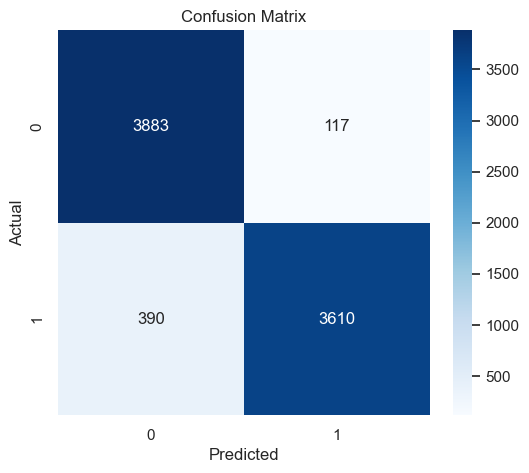

In [26]:
#CONFUSION MATRIX
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test,y_pred_lr),annot=True,fmt='d',cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_resampled, y_train_resampled)

y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test,y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test,y_pred_dt))

print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred_dt))

print("\nROC-AUC:",roc_auc_score(y_test,y_prob_dt))

Accuracy: 0.897375
Precision: 0.8883459565111166
Recall   : 0.909
F1 Score : 0.898554306190535

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      4000
           1       0.89      0.91      0.90      4000

    accuracy                           0.90      8000
   macro avg       0.90      0.90      0.90      8000
weighted avg       0.90      0.90      0.90      8000

Confusion Matrix:
[[3543  457]
 [ 364 3636]]

ROC-AUC: 0.897375


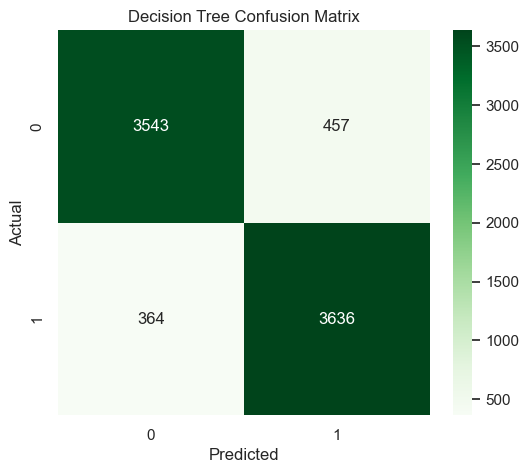

In [28]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42,n_estimators=100)

rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.93475
Precision: 0.971529284164859
Recall   : 0.89575
F1 Score : 0.93210197710718

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.94      4000
           1       0.97      0.90      0.93      4000

    accuracy                           0.93      8000
   macro avg       0.94      0.93      0.93      8000
weighted avg       0.94      0.93      0.93      8000


Confusion Matrix:
[[3895  105]
 [ 417 3583]]

ROC-AUC: 0.9759849062500001


In [30]:
print("Training Accuracy:", rf_model.score(X_train, y_train))
print("Testing Accuracy :", rf_model.score(X_test, y_test))

Training Accuracy: 0.5
Testing Accuracy : 0.5


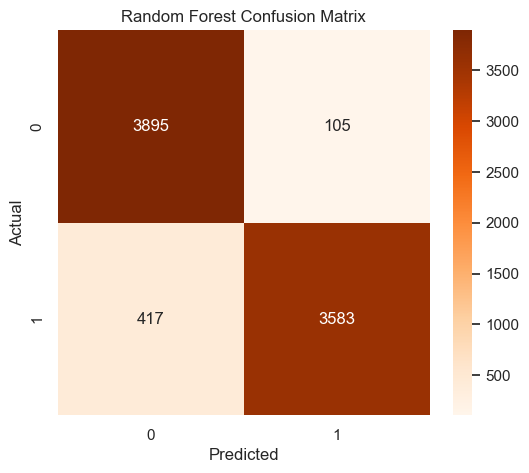

In [31]:
#confusion matrix 
from sklearn.metrics import confusion_matrix 

cm= confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Oranges')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42,eval_metric="logloss")

xgb_model.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.93
Precision: 0.9613733905579399
Recall   : 0.896
F1 Score : 0.927536231884058

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      4000
           1       0.96      0.90      0.93      4000

    accuracy                           0.93      8000
   macro avg       0.93      0.93      0.93      8000
weighted avg       0.93      0.93      0.93      8000


Confusion Matrix:
[[3856  144]
 [ 416 3584]]

ROC-AUC: 0.9744108437500001


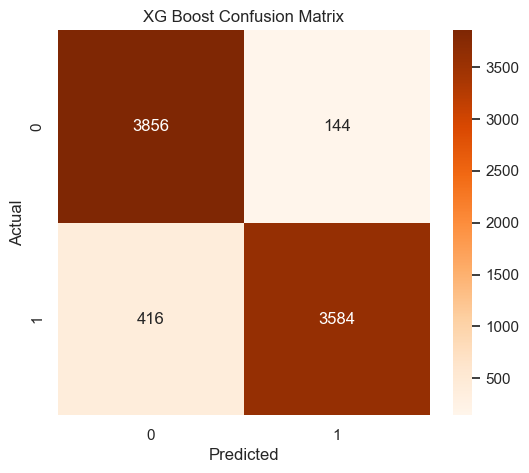

In [33]:
#confusion matrix 
from sklearn.metrics import confusion_matrix 

cm= confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Oranges')

plt.title("XG Boost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_resampled, y_train_resampled)

y_pred_knn = knn_model.predict(X_test_scaled) 
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_knn)) 

Accuracy: 0.918625
Precision: 0.9715573078006196
Recall   : 0.8625
F1 Score : 0.9137862534763608

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      4000
           1       0.97      0.86      0.91      4000

    accuracy                           0.92      8000
   macro avg       0.92      0.92      0.92      8000
weighted avg       0.92      0.92      0.92      8000


Confusion Matrix:
[[3899  101]
 [ 550 3450]]

ROC-AUC: 0.95458915625


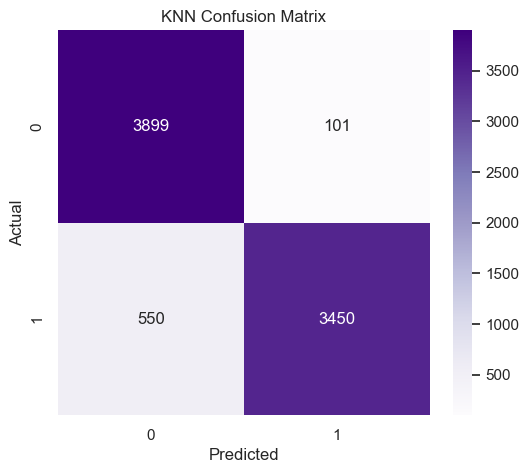

In [35]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Purples')

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf",probability=True,random_state=42)

svm_model.fit(X_train_resampled, y_train_resampled) 

y_pred_svm = svm_model.predict(X_test_scaled) 
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1] 

print("Accuracy:", accuracy_score(y_test, y_pred_svm)) 
print("Precision:", precision_score(y_test, y_pred_svm)) 
print("Recall   :", recall_score(y_test, y_pred_svm)) 
print("F1 Score :", f1_score(y_test, y_pred_svm)) 

print("\nClassification Report:") 
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:") 
print(confusion_matrix(y_test, y_pred_svm)) 

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_svm))  

Accuracy: 0.935875
Precision: 0.9833656778486277
Recall   : 0.88675
F1 Score : 0.9325621138425135

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      4000
           1       0.98      0.89      0.93      4000

    accuracy                           0.94      8000
   macro avg       0.94      0.94      0.94      8000
weighted avg       0.94      0.94      0.94      8000


Confusion Matrix:
[[3940   60]
 [ 453 3547]]

ROC-AUC: 0.9658963749999999


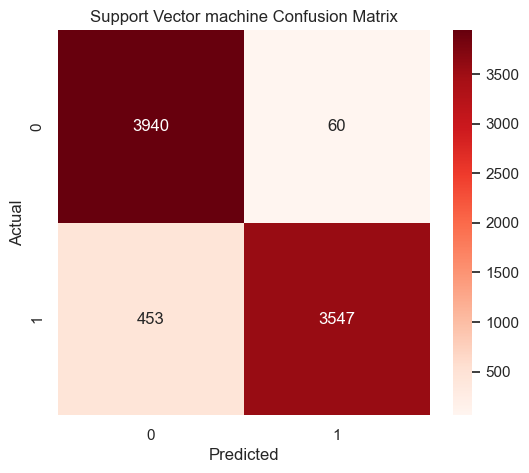

In [37]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds')

plt.title("Support Vector machine Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual") 
plt.show() 

In [38]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Store model names and trained models
models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model, 
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "KNN": knn_model,
    "SVM": svm_model
}

results = []

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.936625,0.968607,0.90250,0.934386,0.978500
1,SVM,0.935875,0.983366,0.88675,0.932562,0.965896
2,Random Forest,0.934750,0.971529,0.89575,0.932102,0.975985
3,XGBoost,0.930000,0.961373,0.89600,0.927536,0.974411
4,KNN,0.918625,0.971557,0.86250,0.913786,0.954589
5,Decision Tree,0.897375,0.888346,0.90900,0.898554,0.897375


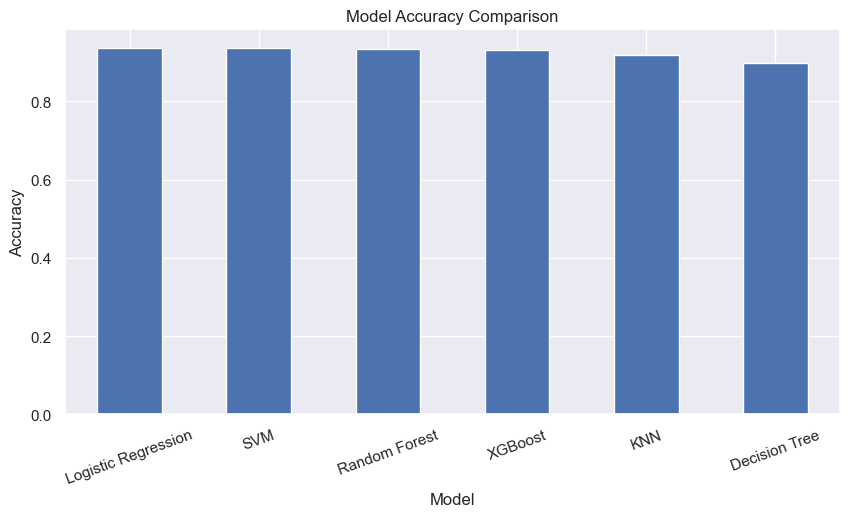

In [39]:
#Visual Comparision 
import matplotlib.pyplot as plt

comparison_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Parameter Grid
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [500, 1000, 2000]
}

lr_search = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_distributions=lr_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

lr_search.fit(X_train_resampled, y_train_resampled)

best_lr = lr_search.best_estimator_

print("Best Parameters:", lr_search.best_params_)

Best Parameters: {'solver': 'liblinear', 'max_iter': 2000, 'C': 0.1}


In [41]:
y_pred_lr = best_lr.predict(X_test_scaled)
y_prob_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Accuracy: 0.936125
Precision: 0.9693301049233253
Recall   : 0.90075
F1 Score : 0.9337825579888558

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      4000
           1       0.97      0.90      0.93      4000

    accuracy                           0.94      8000
   macro avg       0.94      0.94      0.94      8000
weighted avg       0.94      0.94      0.94      8000


Confusion Matrix:
[[3886  114]
 [ 397 3603]]

ROC-AUC: 0.9785110625


In [42]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Parameter Grid
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

knn_search = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=knn_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

knn_search.fit(X_train_resampled, y_train_resampled)

best_knn = knn_search.best_estimator_

print("Best Parameters:", knn_search.best_params_)

Best Parameters: {'weights': 'uniform', 'p': 1, 'n_neighbors': 9, 'metric': 'euclidean'}


In [43]:
y_pred_knn = best_knn.predict(X_test_scaled)
y_prob_knn = best_knn.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_knn))

Accuracy: 0.92175
Precision: 0.981724728726442
Recall   : 0.8595
F1 Score : 0.9165555851772861

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93      4000
           1       0.98      0.86      0.92      4000

    accuracy                           0.92      8000
   macro avg       0.93      0.92      0.92      8000
weighted avg       0.93      0.92      0.92      8000


Confusion Matrix:
[[3936   64]
 [ 562 3438]]

ROC-AUC: 0.9599607187499999


In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Parameter Grid 
dt_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
} 

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_params, 
    cv=5,
    scoring="accuracy", 
    n_jobs=-1
) 

dt_grid.fit(X_train_resampled, y_train_resampled)

best_dt = dt_grid.best_estimator_

print("Best Parameters:", dt_grid.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [46]:
#Evaluate Tuned Decision Tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_rf = best_dt.predict(X_test_scaled)
y_prob_rf = best_dt.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_dt))

Accuracy: 0.897375
Precision: 0.8883459565111166
Recall   : 0.909
F1 Score : 0.898554306190535

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      4000
           1       0.89      0.91      0.90      4000

    accuracy                           0.90      8000
   macro avg       0.90      0.90      0.90      8000
weighted avg       0.90      0.90      0.90      8000


Confusion Matrix:
[[3543  457]
 [ 364 3636]]

ROC-AUC: 0.897375


In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Parameter Grid
rf_params = { 
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_resampled, y_train_resampled)

best_rf = rf_search.best_estimator_

print("Best Parameters:", rf_search.best_params_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}


In [48]:
#Evaluate Tuned Random Forest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_rf = best_rf.predict(X_test_scaled)
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.9365
Precision: 0.973170731707317
Recall   : 0.89775
F1 Score : 0.9339401820546164

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      4000
           1       0.97      0.90      0.93      4000

    accuracy                           0.94      8000
   macro avg       0.94      0.94      0.94      8000
weighted avg       0.94      0.94      0.94      8000


Confusion Matrix:
[[3901   99]
 [ 409 3591]]

ROC-AUC: 0.9767610625


In [49]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Parameter Grid
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_distributions=xgb_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_resampled, y_train_resampled)

best_xgb = xgb_search.best_estimator_

print("Best Parameters:", xgb_search.best_params_)

Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [50]:
#Evaluate Tuned XGBOOST
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_xgb = best_xgb.predict(X_test_scaled)
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_xgb)) 

Accuracy: 0.93675
Precision: 0.9788925438596491
Recall   : 0.89275
F1 Score : 0.9338389121338913

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      4000
           1       0.98      0.89      0.93      4000

    accuracy                           0.94      8000
   macro avg       0.94      0.94      0.94      8000
weighted avg       0.94      0.94      0.94      8000


Confusion Matrix:
[[3923   77]
 [ 429 3571]]

ROC-AUC: 0.9789632812500001


In [51]:
 from sklearn.model_selection import cross_val_score

In [52]:
from sklearn.model_selection import cross_val_score
import pandas as pd

models = { 
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Cross Validation Accuracy": scores.mean(),
        "Standard Deviation": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df = cv_df.sort_values(
    by="Cross Validation Accuracy",
    ascending=False
).reset_index(drop=True)
 
cv_df

,Model,Cross Validation Accuracy,Standard Deviation
0,Random Forest,0.937312,0.002148
1,XGBoost,0.936969,0.002077
2,Decision Tree,0.934656,0.003074


In [53]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

scores_dt = cross_val_score(best_dt,X,y,cv=5,scoring='accuracy')

print("Decision Tree Cross Validation Scores:",scores_dt)
print("Average Accuracy:", scores_dt.mean())
print("Standard Deviation:", scores_dt.std())


Decision Tree Cross Validation Scores: [0.93     0.938    0.936    0.931625 0.936625]
Average Accuracy: 0.93445
Standard Deviation: 0.0030828152717929536


In [54]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

scores_rf = cross_val_score(best_rf,X,y,cv=5,scoring='accuracy')

print("Random Forest Cross Validation Scores:",scores_rf)
print("Average Accuracy:", scores_rf.mean())
print("Standard Deviation:", scores_rf.std()) 


Random Forest Cross Validation Scores: [0.93375  0.9395   0.93825  0.932625 0.93875 ]
Average Accuracy: 0.936575
Standard Deviation: 0.00281691320420065


In [55]:
scores_xgb = cross_val_score(best_xgb,X,y,cv=5,scoring='accuracy')

print("XGBOOST Cross Validation Scores:",scores_xgb) 
print("Average Accuracy:", scores_xgb.mean())
print("Standard Deviation:", scores_xgb.std()) 


XGBOOST Cross Validation Scores: [0.9325   0.939375 0.939375 0.93325  0.93925 ]
Average Accuracy: 0.93675
Standard Deviation: 0.003173129370195914


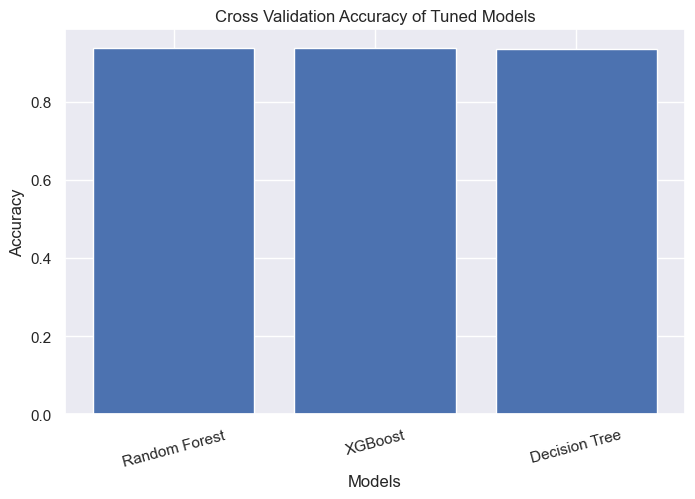

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    cv_df["Model"],
    cv_df["Cross Validation Accuracy"]
)

plt.title("Cross Validation Accuracy of Tuned Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

plt.show()

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = best_rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,Diabetes,0.388134
18,ExerciseAngina,0.238568
2,BMI,0.190461
11,Hypertension,0.049791
16,LDL,0.016284
14,RestingHR,0.014595
0,Age,0.014550
15,HDL,0.014482
7,SleepHours,0.013745
9,FamilyHistory,0.011897


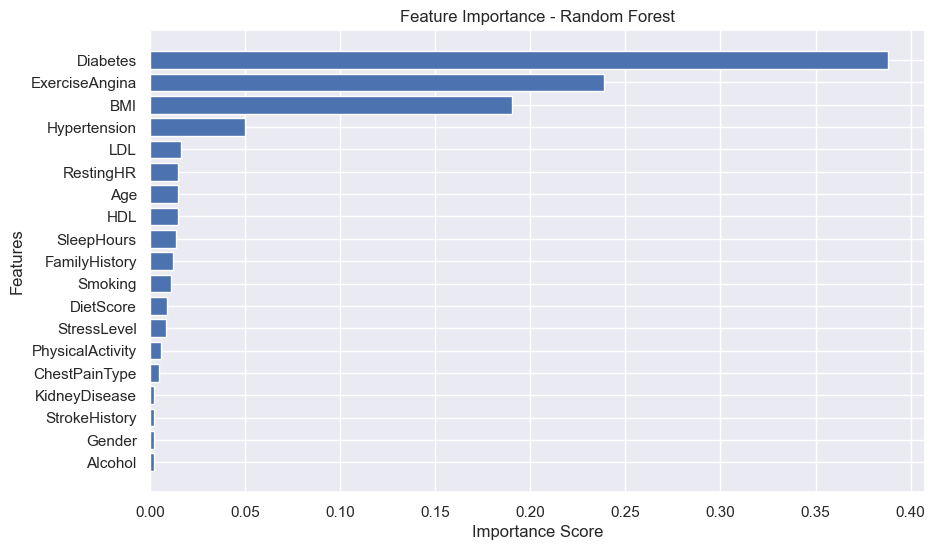

In [58]:
#Visualise
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"] 
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [59]:
import joblib  

joblib.dump(best_lr, "logistic_regression_model.pkl")

print("Logistic Regression model saved successfully.")  

Logistic Regression model saved successfully.


In [60]:
#Verify the model
loaded_model = joblib.load("Logistic_Regression_model.pkl")
         
print(type(loaded_model))  

<class 'sklearn.linear_model._logistic.LogisticRegression'>
